In [1]:
# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Geopandas for maps plots
import geopandas as gpd

# Warnings
# import warnings
# warnings.filterwarnings('ignore')

# Scipy for scientific computation tasks
import scipy
from scipy.signal import savgol_filter

# Plotly
# import plotly.express as px
# import plotly.graph_objects as go
# from plotly.subplots import make_subplots

# Sktime for time series classification and forecasting
# try:
#     import sktime
# except:
#     !pip install sktime
#     import sktime

# from sktime.clustering.k_means import TimeSeriesKMeans
# from sktime.clustering.dbscan import TimeSeriesDBSCAN
# from sktime.dists_kernels import FlatDist, ScipyDist

# Sklearn for machine learning tasks
# import sklearn

# PyTorch for neural networks
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import DataLoader, TensorDataset

In [2]:
!git clone https://github.com/ChileMexicoEpimat/ChileMexicoData.git

Cloning into 'ChileMexicoData'...
remote: Enumerating objects: 174, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 174 (delta 2), reused 15 (delta 2), pack-reused 157 (from 1)
Receiving objects: 100% (174/174), 40.99 MiB | 8.71 MiB/s, done.
Resolving deltas: 100% (85/85), done.
Updating files: 100% (42/42), done.


In [3]:
# Path to data forlder
data_path = '/content/ChileMexicoData/data/'

# Select country
country = 'chile'
#country = 'mexico'

# Select region (Chile) or state (Mexico)
region = 'Metropolitana'
#state = 'Queretaro'

# Choose to work with cases or death (soon with other quantities)
out = 'cases'
# out = 'deaths'

In [4]:
# Country path
country_path = data_path + country + '/'

# Check if region or state is correct
if country == 'chile':
    if region in pd.read_csv(country_path +  'regions_chile.csv').columns:
        print('Correct')
    else:
        print('Incorrect, correct options are:')
        print(pd.read_csv(country_path +  'regions_chile.csv').columns.to_numpy())

# In construction
# elif country == 'mexico':
#     if region in pd.read_csv(country_path +  'states_mexico.csv').values:
#         print('Correct')
#     else:
#         print('Incorrect')

Correct


In [5]:
# Data
try:
    if country == 'chile':
        # Epidemiological data
        data = pd.read_csv(country_path + out + '_' + region + '.csv', index_col=0)
        data.index = pd.to_datetime(data.index)

        # Social determinants data
        ddss = pd.read_csv(country_path + 'ddss_chile.csv', sep=',')
        ddss = ddss[ddss['NOM_REGION'] == region]
        ddss = ddss.drop(columns=['NOM_REGION', 'CLAVE_REGION','CLAVE_MUN'])
        ddss.index = ddss['NOM_MUN']
        ddss = ddss.drop(columns=['NOM_MUN'])
        ddss = ddss.T
        print('Loaded: ' + country + ' ' + region + ' ' + out)
    elif country == 'mexico':
        data = pd.read_csv(country_path + out + '_' + state + '.csv', index_col=0)
        data.index = pd.to_datetime(data.index)

except:
    print('Error')

Loaded: chile Metropolitana cases


In [6]:
# Select some dates
ini_date = '2020-03-01'
end_date = '2021-12-31'

# To datetime
i_date_dt = pd.to_datetime(ini_date)
e_date_dt = pd.to_datetime(end_date)

# Selected dates
data = data.loc[ini_date:end_date]

In [7]:
data

,Alhue,Buin,Calera de Tango,Cerrillos,Cerro Navia,Colina,Conchali,Curacavi,El Bosque,El Monte,...,San Joaquin,San Jose de Maipo,San Miguel,San Pedro,San Ramon,Santiago,Talagante,Tiltil,Vitacura,Desconocido Metropolitana
2020-04-01,0.0,1.0,1.0,4.0,2.0,7.0,4.0,0.0,10.0,0.0,...,11.0,0.0,7.0,0.0,6.0,29.0,5.0,0.0,7.0,0.0
2020-04-03,0.0,6.0,0.0,0.0,5.0,8.0,4.0,0.0,7.0,0.0,...,4.0,0.0,7.0,0.0,3.0,17.0,1.0,0.0,10.0,0.0
2020-04-06,0.0,6.0,0.0,1.0,5.0,3.0,10.0,3.0,2.0,5.0,...,8.0,0.0,10.0,0.0,0.0,61.0,5.0,0.0,14.0,0.0
2020-04-08,0.0,0.0,1.0,6.0,5.0,12.0,6.0,1.0,9.0,2.0,...,6.0,0.0,7.0,0.0,3.0,37.0,3.0,4.0,0.0,0.0
2020-04-10,0.0,9.0,0.0,10.0,6.0,4.0,9.0,1.0,18.0,2.0,...,10.0,4.0,13.0,0.0,6.0,50.0,4.0,0.0,5.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-17,-1.0,22.0,2.0,4.0,24.0,44.0,9.0,5.0,26.0,9.0,...,8.0,7.0,13.0,4.0,11.0,89.0,8.0,3.0,11.0,-20.0
2021-12-20,0.0,20.0,-2.0,6.0,14.0,25.0,11.0,4.0,10.0,7.0,...,9.0,1.0,16.0,2.0,7.0,60.0,5.0,3.0,8.0,15.0
2021-12-24,1.0,26.0,1.0,3.0,10.0,24.0,5.0,12.0,14.0,2.0,...,5.0,2.0,14.0,2.0,8.0,116.0,9.0,0.0,26.0,102.0
2021-12-27,-1.0,6.0,3.0,4.0,6.0,30.0,11.0,10.0,13.0,2.0,...,8.0,4.0,13.0,0.0,6.0,63.0,8.0,1.0,30.0,164.0


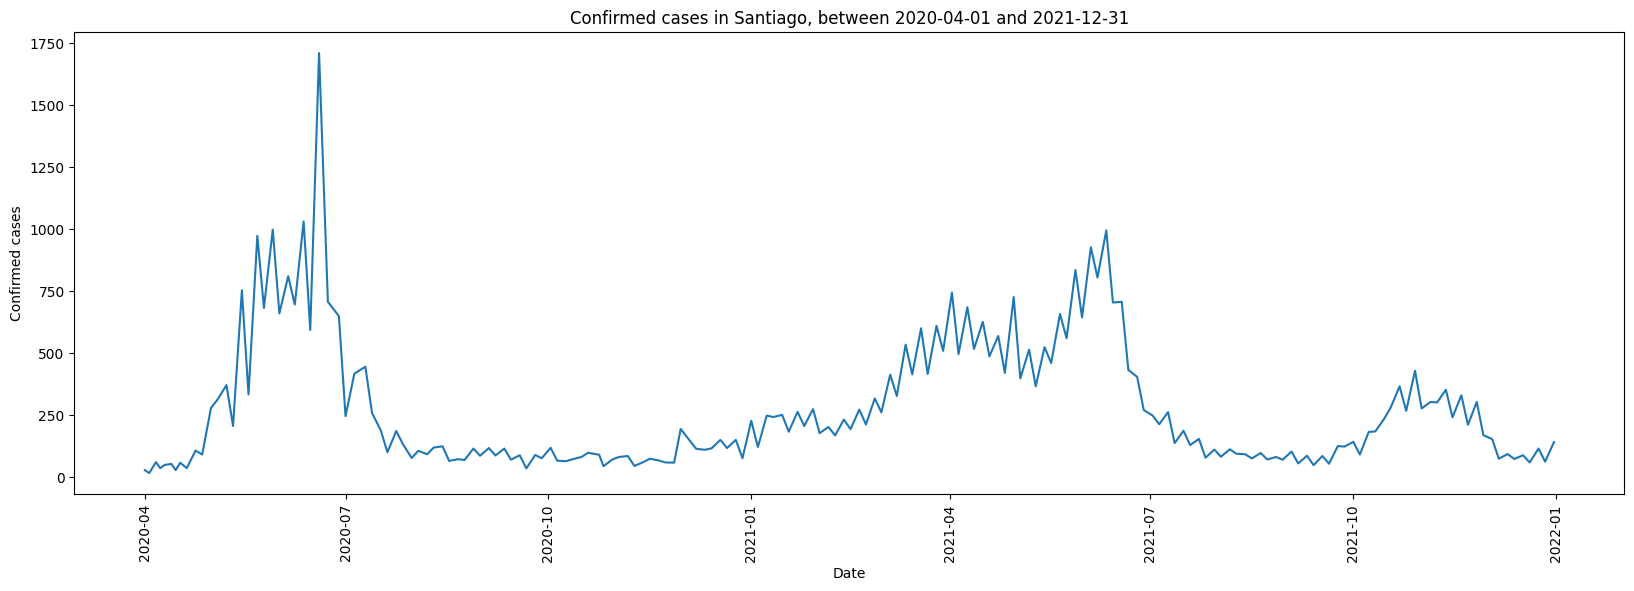

In [8]:
# Plots
comune = "Santiago"

plt.figure(figsize=(20, 6))
plt.plot(data[comune])
plt.xticks(rotation=90)
plt.xlabel('Date')

if out == 'cases':
    text = 'Confirmed cases'
elif out == 'deaths':
    text = 'Reported deaths'

plt.ylabel(text)
plt.title(text+ ' in ' + comune + ', between ' + data.index[0].strftime('%Y-%m-%d') + ' and ' + data.index[-1].strftime('%Y-%m-%d'))
plt.show()

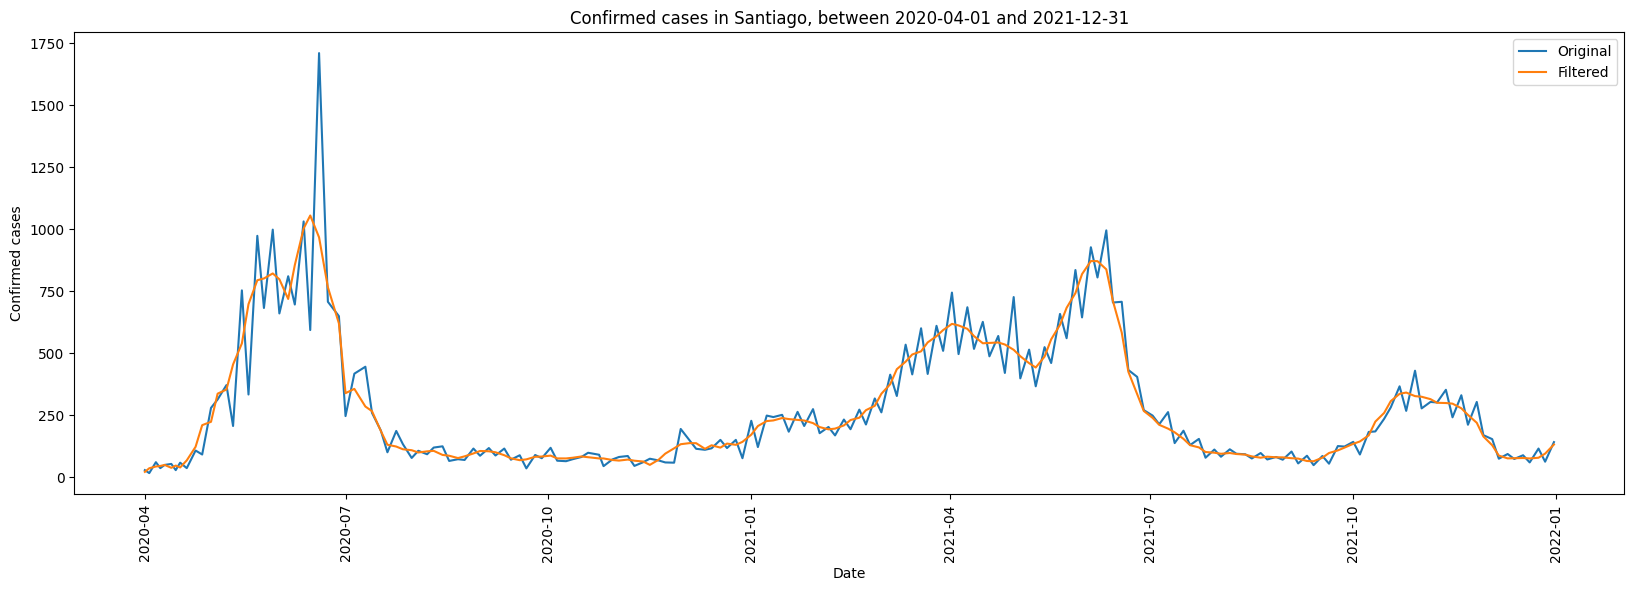

In [9]:
# Example of filtering
filtered_data = data.apply(savgol_filter, args=(8, 3))

plt.figure(figsize=(20, 6))
plt.plot(data[comune], label='Original')
plt.plot(filtered_data[comune], label='Filtered')
plt.xticks(rotation=90)
plt.xlabel('Date')

if out == 'cases':
    text = 'Confirmed cases'
elif out == 'deaths':
    text = 'Reported deaths'

plt.ylabel(text)
plt.title(text+ ' in ' + comune + ', between ' + data.index[0].strftime('%Y-%m-%d') + ' and ' + data.index[-1].strftime('%Y-%m-%d'))
plt.legend()
plt.show()

In [10]:
# Invalid columns for Chile
invalid_cols = [
    'POBREZA_ING_EXTR',
    'MARGINACION',
    'PRIORIDAD_SOCIAL',
    'REZAGO_SOCIAL',
    'VULNERABILIDAD_SOCIAL']

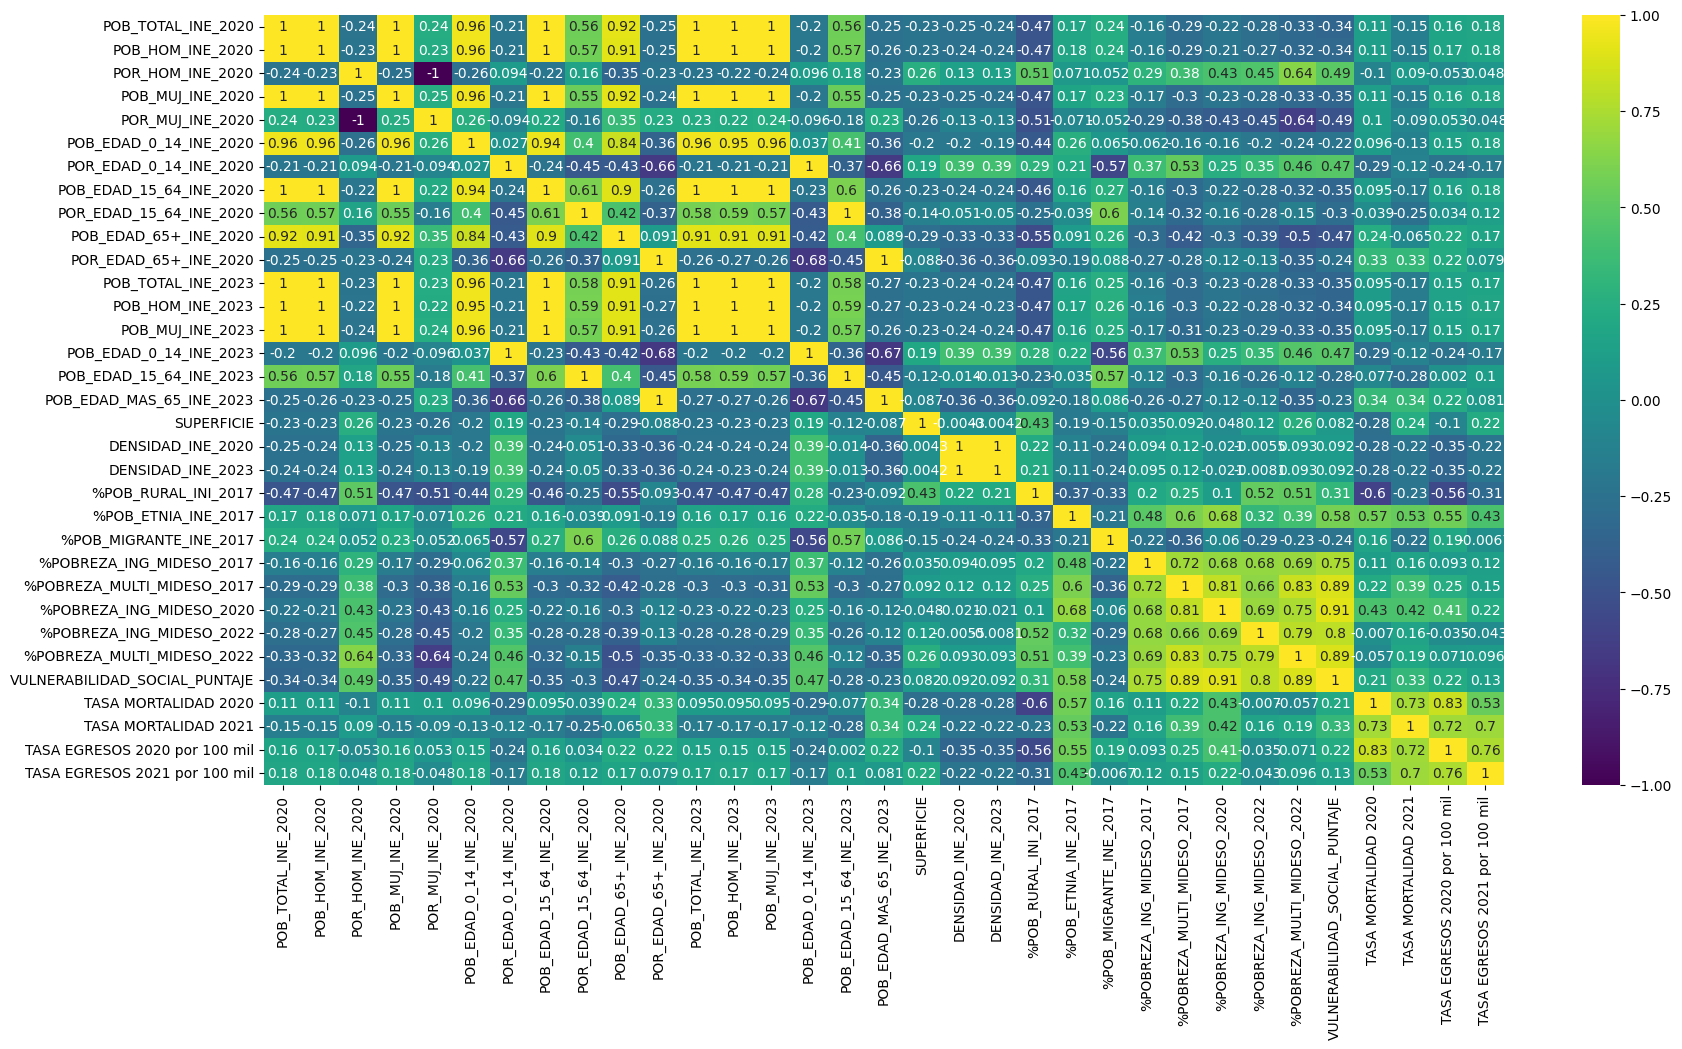

In [11]:
# Correlation between Social Determinants
ddss_cor = ddss.T.drop(columns=invalid_cols)
df_cor = ddss_cor.corr()

# Example of heatmap
plt.figure(figsize=(20,10))
sns.heatmap(df_cor, annot=True, cmap="viridis")
plt.show()

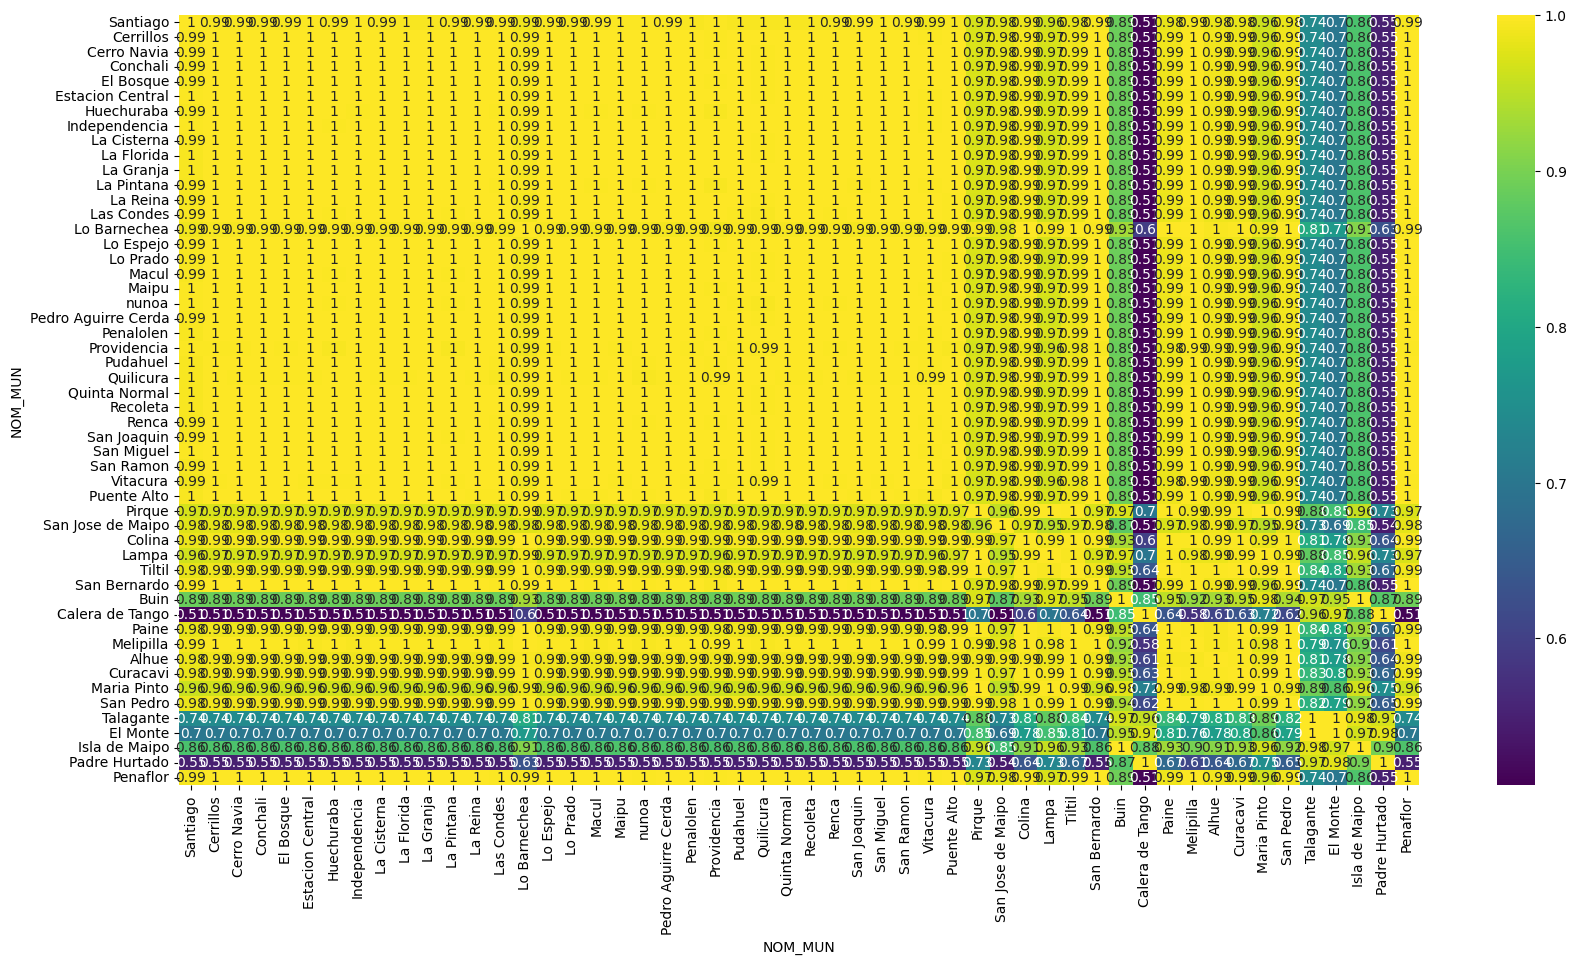

In [12]:
# Correlation between Comunes
ddss_cor = ddss.T.drop(columns=invalid_cols).T
df_cor = ddss_cor.corr()

# Example of heatmap
plt.figure(figsize=(20,10))
sns.heatmap(df_cor, annot=True, cmap="viridis")
plt.show()

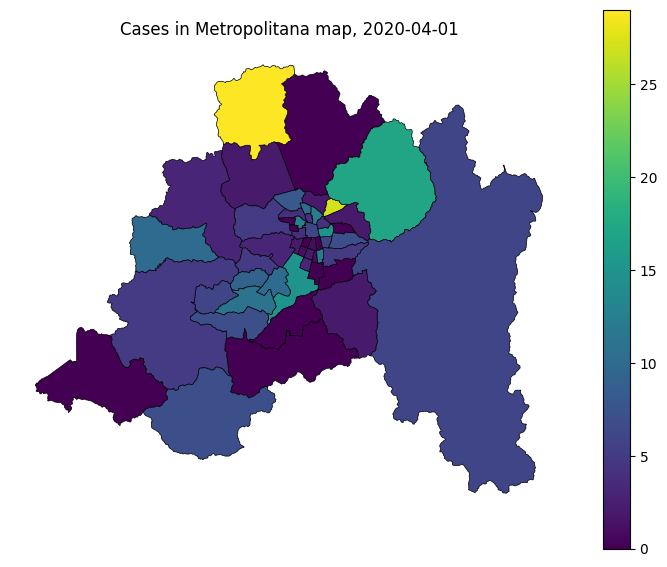

In [34]:
# Example of map plot
maps_path = country_path + 'maps/'
maps = gpd.read_file(maps_path + 'maps_chile.shp')
map_reg = maps[maps['Region'] == 'Región Metropolitana de Santiago']
map_reg = map_reg.drop(columns=['Region'])

vals_plot = data.T[data.index[0]].values[:-1]

map_reg[data.index[0]] = vals_plot

fig, ax = plt.subplots(1, 1, figsize=(9, 7))

map_reg.plot(column=data.index[0],
                cmap="viridis",
                linewidth=0.5,
                edgecolor="black",
                ax=ax,
                figsize=(9,7))

plt.axis("off")
bar_info = plt.cm.ScalarMappable(cmap="viridis",
                              norm=plt.Normalize(vmin=0, vmax=np.max(vals_plot)))

cbar = fig.colorbar(bar_info, ax=ax)

ax.set_title(f'Cases in {region} map, ' + data.index[0].strftime('%Y-%m-%d'))
ax.axis("off")
plt.show()